In [1]:
# numerical library:
import numpy as np

# data manipulation library:
import pandas as pd

# standard packages used to handle files:
import sys
import os 
import glob
import time

# scikit-learn machine learning library:
import sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error

# plotting:
import matplotlib.pyplot as plt
import seaborn as sns

# tell matplotlib that we plot in a notebook:
%matplotlib inline

disclaimer: ik heb nog geen goede motivatie toegevoegd want te druk
ik heb ergens een aanpassing gemaakt en ik weet niet meer wat en nu is mijn Kaggle score oplossing niet meer te vinden
sommige dingen heb ik opnieuw gerunt en zijn slechter 
Het laatste gerunde met optuna search en xgboost was het beste, maar die oplossing zou ik niet meer kunnen bekomen als ik het opnieuw run.

## Step 1: data analysis

In [2]:
data_folder = "./"

In [3]:
train_data = pd.read_csv(data_folder + "training_data.csv")
test_data = pd.read_csv(data_folder + "test_data.csv")

In [4]:
train_data.head()

,active_power,timestamp,pitch_angle,reactive_power,nacelle_angle,nacelle_temp,wind_speed1,wind_speed2,wind_speed_avg,wind_angle,...,outdoor_temp,rotor_angular_velocity,rotor_bearing_temp,weather_temp,pressure,humidity,weather_wind_speed,weather_wind_angle,rain_1h,snow_1h
0,801.22998,2013-01-01 00:00:00,-1.0,67.559998,286.00000,20.129999,7.52,7.76,7.64,286.19000,...,5.44,16.950001,26.049999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
1,943.16998,2013-01-01 00:10:00,-1.0,70.260002,286.00000,21.420000,8.18,8.45,8.31,288.32999,...,5.74,17.139999,26.100000,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
2,998.48999,2013-01-01 00:20:00,-1.0,75.330002,286.00000,22.049999,8.29,8.66,8.47,293.04001,...,6.09,17.150000,26.219999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
3,837.96002,2013-01-01 00:30:00,-1.0,82.739998,286.00000,22.299999,7.89,8.24,8.06,294.01999,...,6.35,16.910000,26.309999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
4,871.57001,2013-01-01 00:40:00,-1.0,82.349998,294.17999,22.600000,7.86,8.20,8.03,299.22000,...,6.51,16.920000,26.389999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0


In [ ]:
train_data['timestamp'] = pd.to_datetime(train_data['timestamp'])
test_data['timestamp'] = pd.to_datetime(test_data['timestamp'])

# time based features
for df in [train_data, test_data]:
    df['month'] = df['timestamp'].dt.month
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

# angle based features
angle_cols = ['wind_angle', 'vane_angle', 'weather_wind_angle'] 

# check if these columns exist before trying to transform them
existing_angle_cols = [c for c in angle_cols if c in train_data.columns]

for col in existing_angle_cols:
    # transform train
    train_data[f'{col}_sin'] = np.sin(np.deg2rad(train_data[col]))
    train_data[f'{col}_cos'] = np.cos(np.deg2rad(train_data[col]))
    
    # transform test
    test_data[f'{col}_sin'] = np.sin(np.deg2rad(test_data[col]))
    test_data[f'{col}_cos'] = np.cos(np.deg2rad(test_data[col]))
    
    # drop original angle column to prevent model confusion
    train_data.drop(columns=[col], inplace=True)
    test_data.drop(columns=[col], inplace=True)

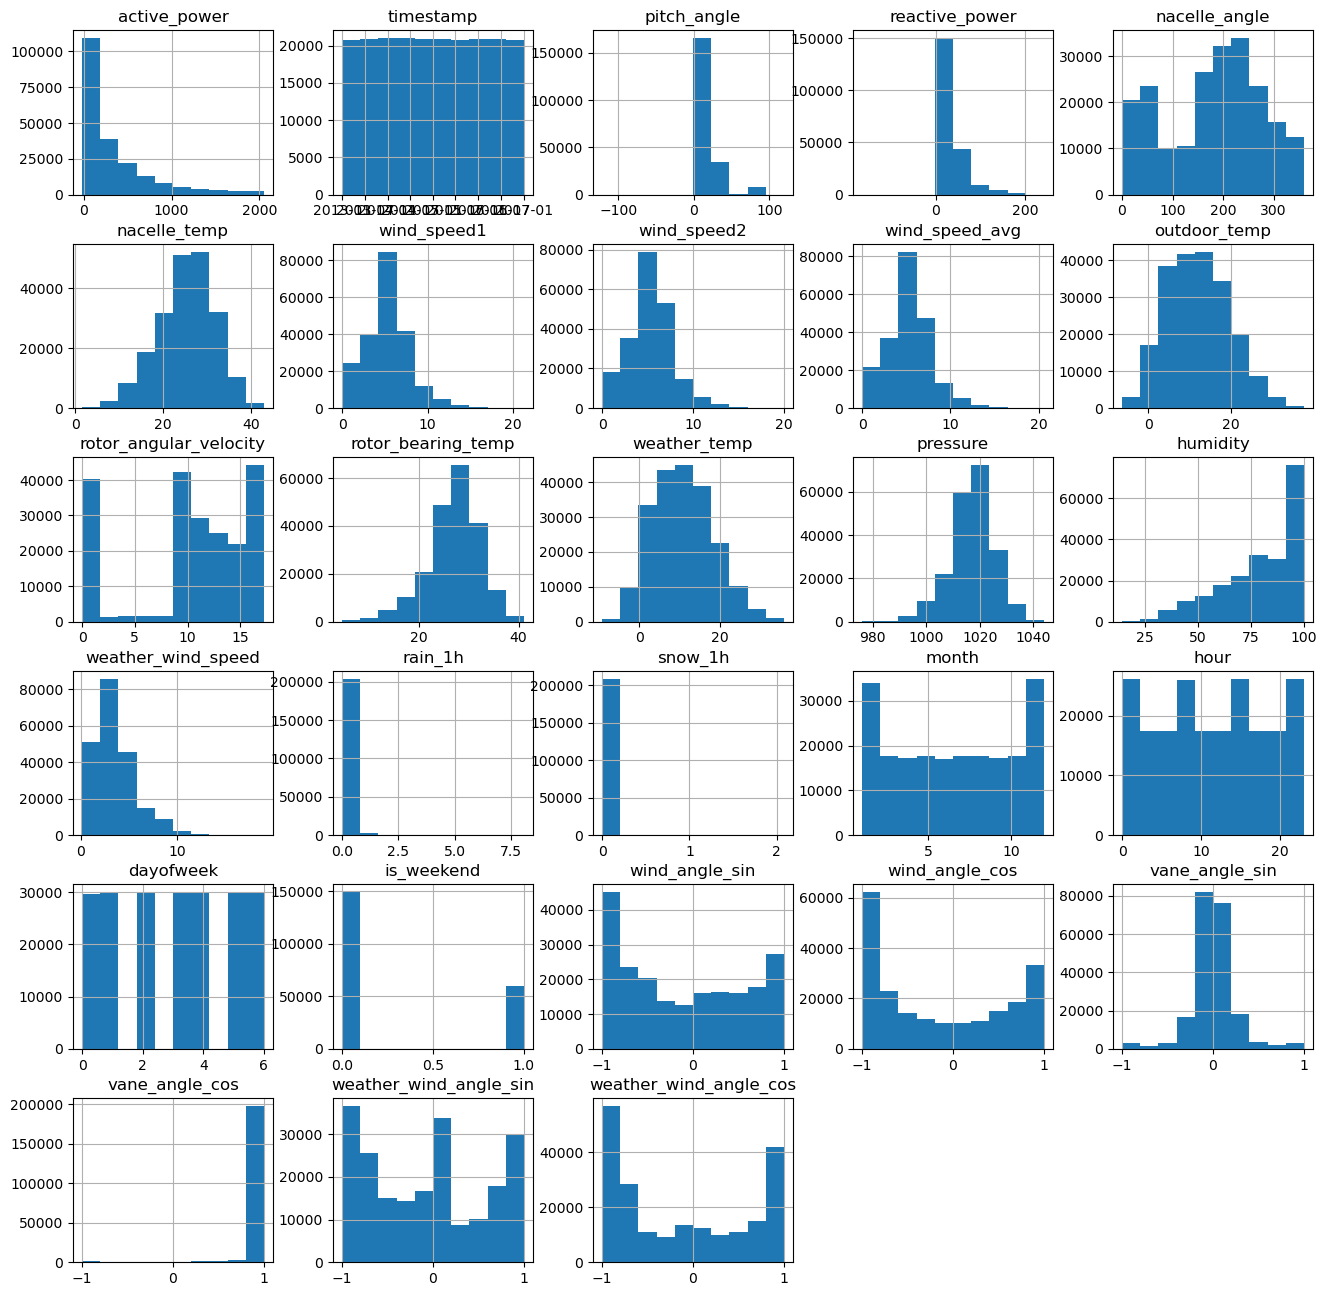

In [6]:
# histograms
train_data.hist(figsize = (16,16)) # figsize: (width,height)
plt.show()

In [7]:
print(train_data.shape, test_data.shape)

(208910, 28) (52228, 27)


In [8]:
print(train_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208910 entries, 0 to 208909
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   active_power            208910 non-null  float64       
 1   timestamp               208910 non-null  datetime64[ns]
 2   pitch_angle             208910 non-null  float64       
 3   reactive_power          208910 non-null  float64       
 4   nacelle_angle           208910 non-null  float64       
 5   nacelle_temp            208910 non-null  float64       
 6   wind_speed1             208910 non-null  float64       
 7   wind_speed2             208910 non-null  float64       
 8   wind_speed_avg          208910 non-null  float64       
 9   outdoor_temp            208910 non-null  float64       
 10  rotor_angular_velocity  208910 non-null  float64       
 11  rotor_bearing_temp      208910 non-null  float64       
 12  weather_temp            208910

In [9]:
print(train_data.describe())

        active_power                      timestamp    pitch_angle  \
count  208910.000000                         208910  208910.000000   
mean      333.816039  2014-12-31 23:05:33.522569472      10.598804   
min       -18.490000            2013-01-01 00:00:00    -121.260000   
25%        24.459999            2014-01-01 15:32:30      -0.990000   
50%       170.530000            2014-12-31 05:35:00      -0.990000   
75%       467.130000            2015-12-31 07:07:30       0.500000   
max      2051.120100            2016-12-31 04:10:00     119.070000   
std       427.064175                            NaN      23.263701   

       reactive_power  nacelle_angle   nacelle_temp    wind_speed1  \
count   208910.000000  208910.000000  208910.000000  208910.000000   
mean        31.602240     181.410901      25.247184       5.245032   
min       -165.550000       0.030000       1.560000       0.000000   
25%          9.600000     100.120000      21.219999       3.790000   
50%         26.8500

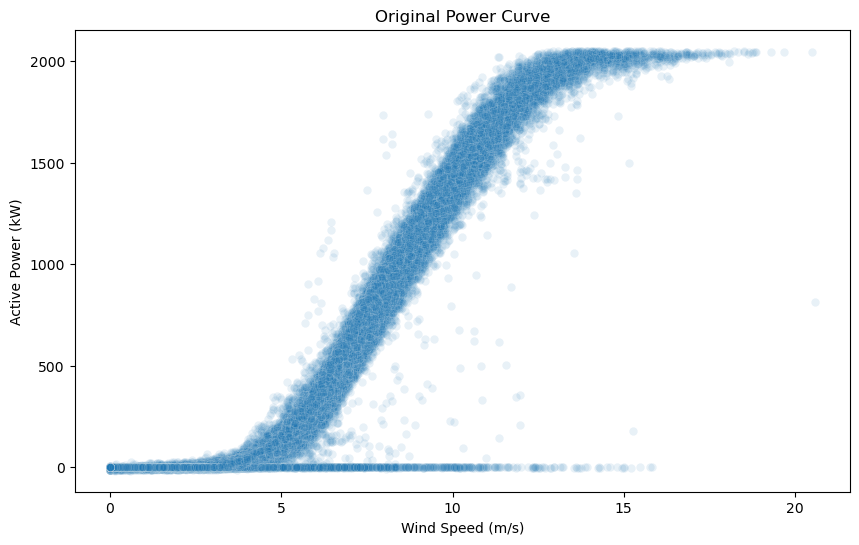

In [12]:
# plot wind speed vs active power
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_data['wind_speed_avg'], y=train_data['active_power'], alpha=0.1)
plt.title('Original Power Curve')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Active Power (kW)')
plt.show()

In [ ]:
print(f"Original dataset shape: {train_data.shape}")

# remove negative power 
# only keep rows where power is >= 0
train_data_clean = train_data[train_data['active_power'] >= 0].copy()

# remove outliers
# if wind speed > 4 m/s AND power is very low < 10 kW, it's an outlier.

mask_stopped = (train_data_clean['wind_speed_avg'] > 4) & (train_data_clean['active_power'] < 10)
train_data_clean = train_data_clean[~mask_stopped]

print(f"Cleaned dataset shape: {train_data_clean.shape}")
print(f"Rows removed: {train_data.shape[0] - train_data_clean.shape[0]}")

Original dataset shape: (208910, 28)
Cleaned dataset shape: (169366, 28)
Rows removed: 39544


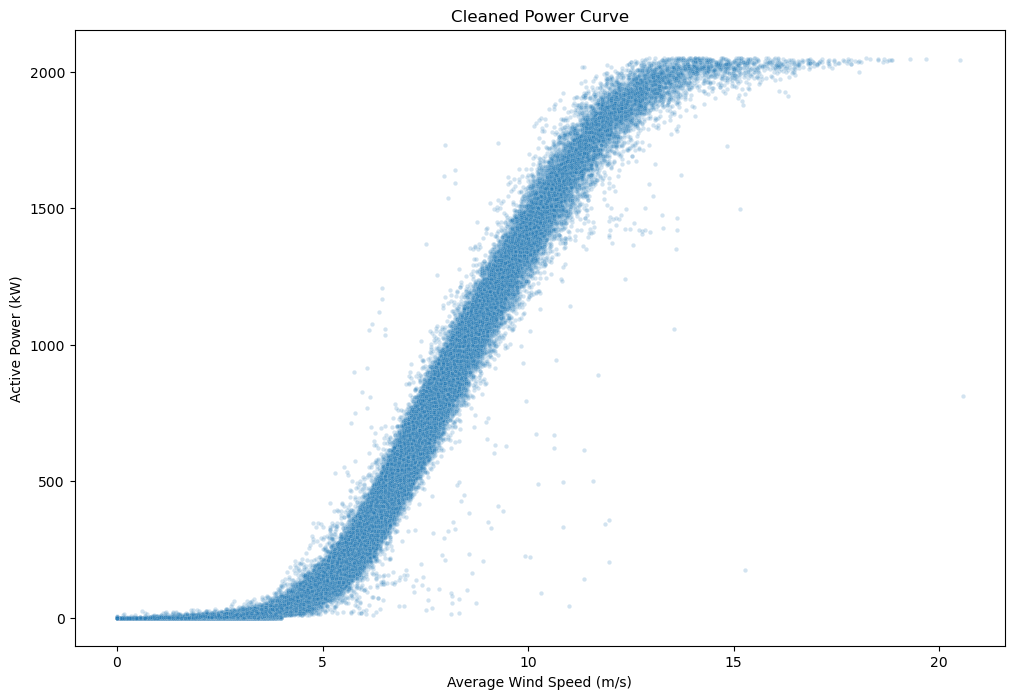

In [14]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=train_data_clean['wind_speed_avg'], y=train_data_clean['active_power'], alpha=0.2, s=10)
plt.title('Cleaned Power Curve')
plt.xlabel('Average Wind Speed (m/s)')
plt.ylabel('Active Power (kW)')
plt.show()

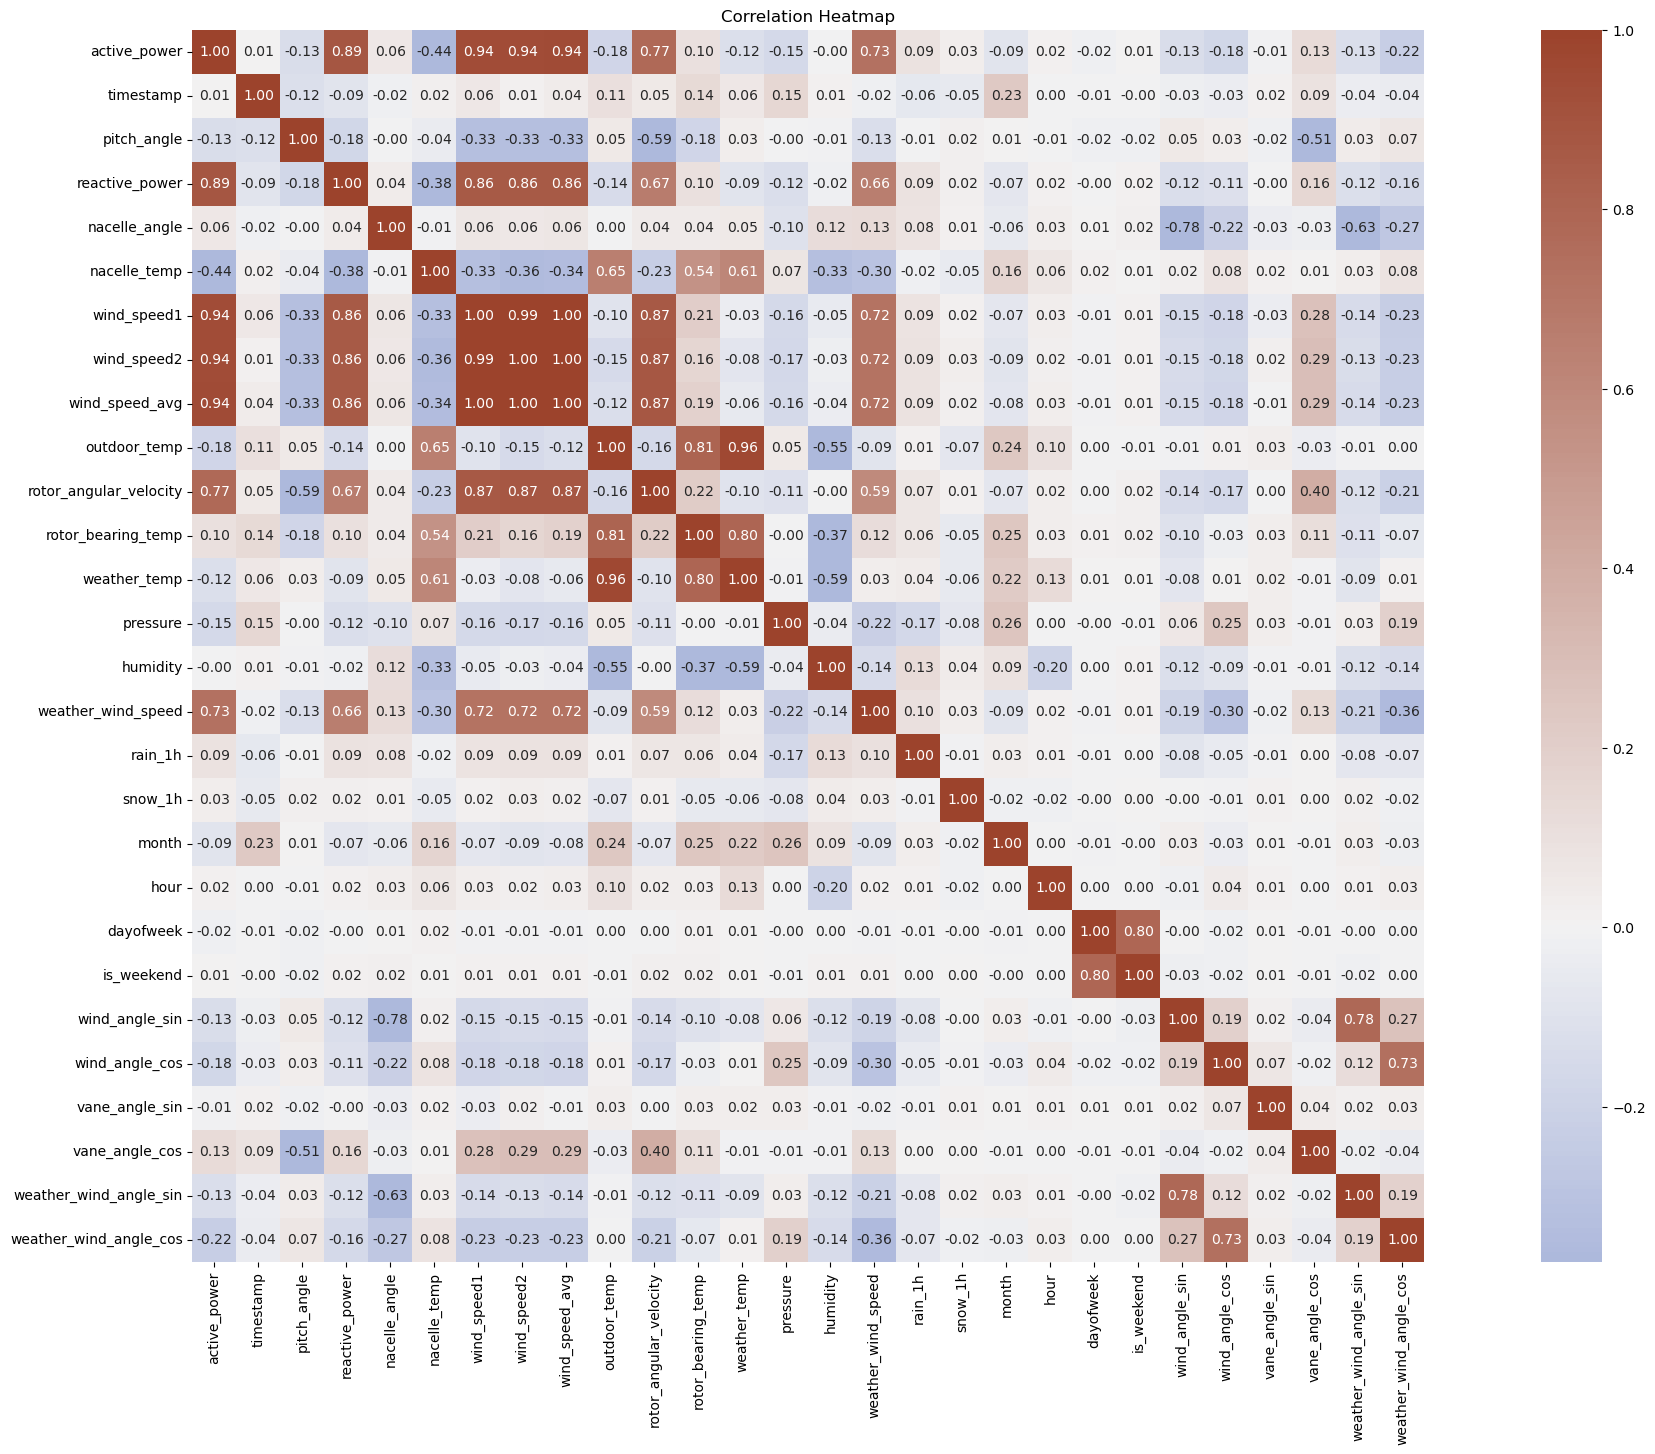

In [15]:
# Create a heatmap of correlations between all variables:
plt.figure(figsize=(30, 16))
corr = train_data_clean.corr()
mask = np.triu(corr)
cmap = sns.diverging_palette(260, 20, s=75, l=40, n=5, center="light", as_cmap=True)
sns.heatmap(corr, cmap=cmap, center=0, mask=None, annot=True, fmt='.2f', square=True, robust=True)

plt.title('Correlation Heatmap')
plt.show()

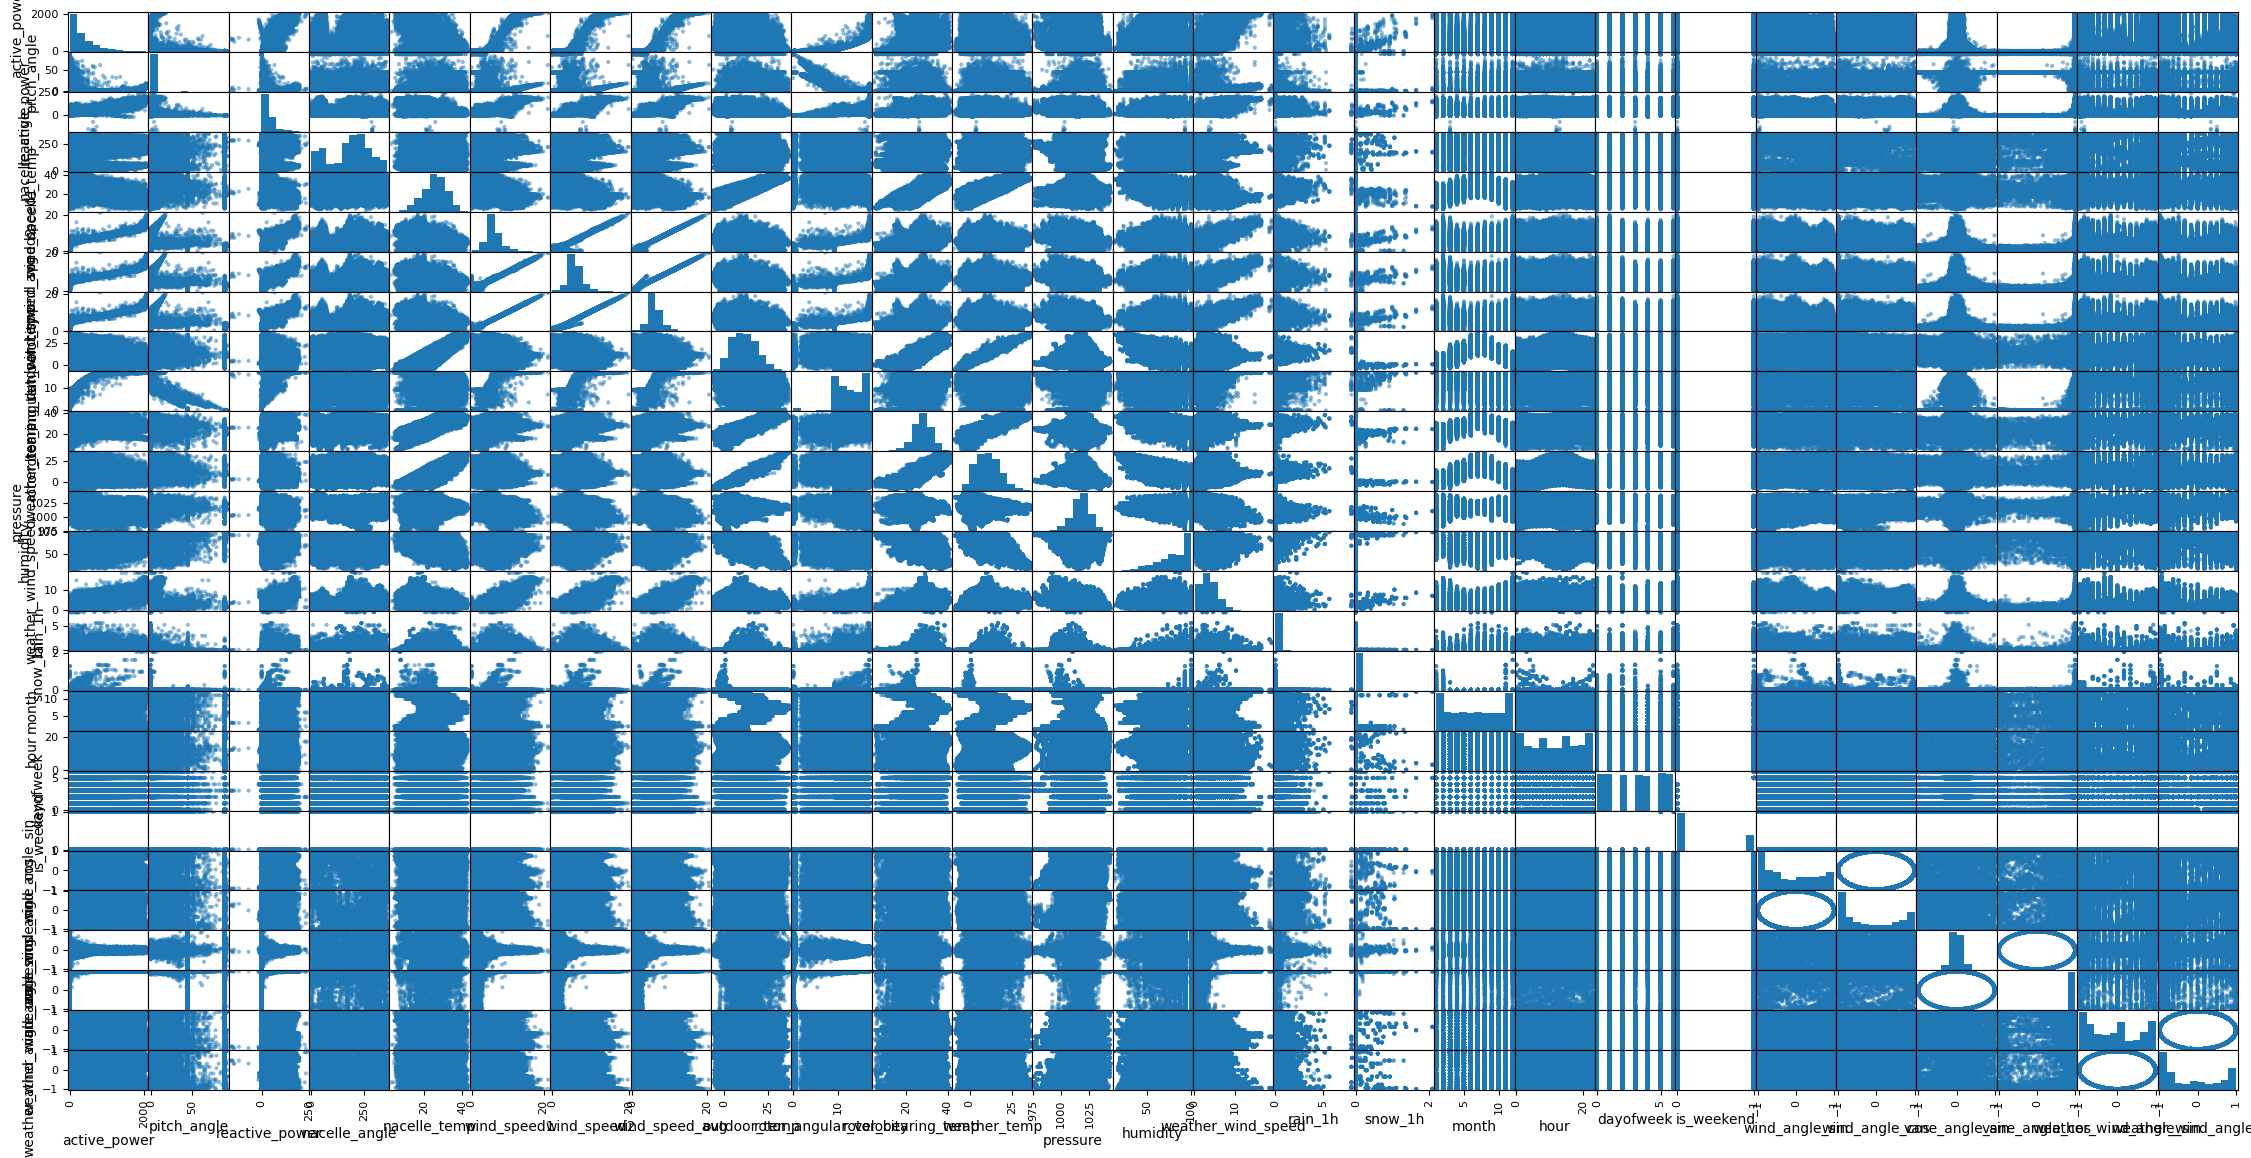

In [16]:
from pandas.plotting import scatter_matrix
scatter_matrix(train_data_clean,figsize = (28,14))
plt.show()

## Step 2: validation set(s) and test set(s)

In [18]:
# chronological order
train_data_clean = train_data_clean.sort_values("timestamp").reset_index(drop=True)

In [19]:
train_data_clean = train_data_clean.drop(['timestamp'], axis=1)
test_data_clean = test_data.drop(['timestamp'], axis=1)

In [22]:
from sklearn.model_selection import TimeSeriesSplit

# prepare X and y
# dropping 'active_power' for features. 
X = train_data_clean.drop(['active_power'], axis=1) 
y = train_data_clean['active_power']

# initialize Time Series Split
# n_splits=5 means we will train/validate 5 times, expanding the window each time
tscv = TimeSeriesSplit(n_splits=5,  test_size=int(len(X)*0.1))
    

## Step 3: Training and optimising your first model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Initialize the model
# Linear Regression fits a straight line: y = mx + b
model = LinearRegression()

rmse_scores = []
mae_scores = []

print("Starting Time Series Cross-Validation with Linear Regression...\n")

# Run the loop 
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Split data using the indices from TimeSeriesSplit
    # .iloc is necessary because X and y are Pandas DataFrames/Series
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the validation set
    y_pred = model.predict(X_val)
    
    # Calculate Errors
    # RMSE (Root Mean Squared Error) penalizes large errors heavily
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"Fold {fold}: RMSE = {rmse:.2f} kW")

print("-" * 30)
print(f"Average RMSE across all folds: {np.mean(rmse_scores):.2f} kW")
print(f"Average MAE: {np.mean(mae_scores):.2f} kW")

Starting Time Series Cross-Validation with Linear Regression...

Fold 0: RMSE = 100.91 kW
Fold 1: RMSE = 88.62 kW
Fold 2: RMSE = 112.60 kW
Fold 3: RMSE = 84.93 kW
Fold 4: RMSE = 87.07 kW
------------------------------
Average RMSE across all folds: 94.83 kW
Average MAE: 67.58 kW


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Model
# n_estimators=100: Uses 100 different trees to vote on the answer
# n_jobs=-1: Uses all your CPU cores to make it faster
model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

rmse_scores = []
mae_scores = []

print("Starting Time Series Cross-Validation with Random Forest...\n")

# Run the loop
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Split data
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Score
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"Fold {fold}: RMSE = {rmse:.2f} kW")

print("-" * 30)
print(f"Average RMSE: {np.mean(rmse_scores):.2f} kW")
print(f"Average MSE: {np.mean(mae_scores):.2f} kW")

Starting Time Series Cross-Validation with Random Forest...

Fold 0: RMSE = 43.22 kW
Fold 1: RMSE = 23.97 kW
Fold 2: RMSE = 33.85 kW
Fold 3: RMSE = 31.33 kW
Fold 4: RMSE = 17.14 kW
------------------------------
Average RMSE: 29.90 kW
Average MSE: 13.28 kW


In [25]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the Gradient Boosting Model
# standard defaults: n_estimators=100, learning_rate=0.1, max_depth=3
model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5,        # Slightly deeper trees often help with complex wind curves
    random_state=42
)

rmse_scores = []
mae_scores = []

print("Starting Time Series Cross-Validation with Gradient Boosting...\n")

# Run the loop 
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Split
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Score
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"Fold {fold}: RMSE = {rmse:.2f} kW")

print("-" * 30)
print(f"Average RMSE: {np.mean(rmse_scores):.2f} kW")
print(f"Average MSE: {np.mean(mae_scores):.2f} kW")

Starting Time Series Cross-Validation with Gradient Boosting...

Fold 0: RMSE = 42.87 kW
Fold 1: RMSE = 22.97 kW
Fold 2: RMSE = 31.41 kW
Fold 3: RMSE = 32.39 kW
Fold 4: RMSE = 17.62 kW
------------------------------
Average RMSE: 29.45 kW
Average MSE: 13.62 kW


In [ ]:
from catboost import CatBoostRegressor

# Initialize the CatBoost Model
# iterations: Equivalent to n_estimators (how many trees to build).
# learning_rate: How much each tree contributes (lower is usually better but requires more iterations).
# depth: Depth of the trees (CatBoost defaults to 6, RF usually has no limit).
# verbose=0: Mutes the output (CatBoost is very chatty by default).
model = CatBoostRegressor(
    iterations=500, 
    learning_rate=0.1, 
    depth=6, 
    random_seed=42,
    verbose=0  # Set to 100 to see progress every 100 trees
)

rmse_scores = []
mae_scores = []

print("Starting Time Series Cross-Validation with CatBoost...\n")

# Run the loop 
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Split data
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Score
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"Fold {fold}: RMSE = {rmse:.2f} kW")

print("-" * 30)
print(f"Average RMSE: {np.mean(rmse_scores):.2f} kW")
print(f"Average MSE: {np.mean(mae_scores):.2f} kW")

Starting Time Series Cross-Validation with CatBoost...

Fold 0: RMSE = 41.43 kW
Fold 1: RMSE = 22.25 kW
Fold 2: RMSE = 28.28 kW
Fold 3: RMSE = 33.34 kW
Fold 4: RMSE = 16.88 kW
------------------------------
Average RMSE: 28.44 kW
Average MSE: 13.98 kW


In [ ]:
from xgboost import XGBRegressor

# 1. Initialize XGBoost
# n_jobs=-1 uses all CPU cores (much faster than sklearn's GBR)
model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

rmse_scores = []
mae_scores = []

print("Starting Time Series Cross-Validation with XGBoost...\n")

# 2. Run the loop
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Split
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Score
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"Fold {fold}: RMSE = {rmse:.2f} kW")

print("-" * 30)
print(f"Average RMSE: {np.mean(rmse_scores):.2f} kW")
print(f"Average MSE: {np.mean(mae_scores):.2f} kW")

Starting Time Series Cross-Validation with XGBoost...

Fold 0: RMSE = 42.14 kW
Fold 1: RMSE = 23.20 kW
Fold 2: RMSE = 31.43 kW
Fold 3: RMSE = 32.40 kW
Fold 4: RMSE = 17.55 kW
------------------------------
Average RMSE: 29.34 kW
Average MSE: 13.62 kW


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

# Define the Parameter Grid 
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0] # % of features used per tree
}

# Setup the Model
xgb = XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42)

# Setup the Search
# n_iter=20 means "Try 20 random combinations"
random_search = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_dist, 
    n_iter=20,           
    scoring='neg_root_mean_squared_error', # Sklearn tries to MAXIMIZE score, so we use negative RMSE
    cv=tscv,        
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Tuning hyperparameters... this might take a minute...")
random_search.fit(X, y)

# Result
print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f"\nBest RMSE Score: {-random_search.best_score_:.2f} kW")

# Build Final Model with the Best Parameters
best_params = random_search.best_params_

final_model = XGBRegressor(
    **best_params,  # Unpacks the dictionary automatically
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

# Train on EVERYTHING (All training data)
final_model.fit(X, y)
print("Final model trained and ready for test_data.csv!")

Tuning hyperparameters... this might take a minute...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters Found:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best RMSE Score: 23.74 kW
Final model trained and ready for test_data.csv!


In [ ]:
import optuna
from xgboost import XGBRegressor

def objective(trial):
    """
    The objective function is what Optuna runs 20 times.
    It picks params, trains, CVs, and returns the Average RMSE.
    """
    
    # Suggest Parameters (The "Search Space")
    # Optuna allows ranges (low, high), not just fixed lists.
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # log=True explores small values more carefully
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5), # Good extra param to prevent overfitting
        
        # Fixed params
        'objective': 'reg:squarederror',
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': 0 # Silence XGBoost warnings during tuning
    }
    
    # Initialize Model with suggested params
    model = XGBRegressor(**params)
    
    scores = []
    
    # Manual Time Series Cross-Validation Loop
    # We do this inside the trial to get the average error for these specific params
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        scores.append(rmse)
    
    # Return the average RMSE across all folds
    return np.mean(scores)

# Create the Study
print("Starting Optuna Optimization...")
study = optuna.create_study(direction='minimize') # We want to MINIMIZE RMSE
study.optimize(objective, n_trials=100) # Run 100 trials

# The Results
print("\n----------------------------------")
print("Best Parameters Found:")
print(study.best_params)
print(f"\nBest Average RMSE: {study.best_value:.2f} kW")
print("----------------------------------")

# Build Final Model
# Merge the best discovered params with the fixed required params
final_params = study.best_params
final_params['objective'] = 'reg:squarederror'
final_params['n_jobs'] = -1
final_params['random_state'] = 42

final_model = XGBRegressor(**final_params)

# Train on EVERYTHING
final_model.fit(X, y)
print("Final Optuna-tuned model trained and ready!")

[I 2025-12-02 00:34:01,289] A new study created in memory with name: no-name-77187c56-9848-4194-a11b-11cc18fad197


Starting Optuna Optimization...


[I 2025-12-02 00:34:15,752] Trial 0 finished with value: 24.808844789241626 and parameters: {'n_estimators': 800, 'learning_rate': 0.010751777218538216, 'max_depth': 6, 'subsample': 0.7835681656551315, 'colsample_bytree': 0.661717025372326, 'min_child_weight': 5}. Best is trial 0 with value: 24.808844789241626.
[I 2025-12-02 00:34:21,777] Trial 1 finished with value: 26.112510973143895 and parameters: {'n_estimators': 500, 'learning_rate': 0.017885733115986863, 'max_depth': 4, 'subsample': 0.9587491209271353, 'colsample_bytree': 0.9597724489083773, 'min_child_weight': 2}. Best is trial 0 with value: 24.808844789241626.
[I 2025-12-02 00:34:25,814] Trial 2 finished with value: 25.607746336802013 and parameters: {'n_estimators': 400, 'learning_rate': 0.1930043056323917, 'max_depth': 3, 'subsample': 0.6361679289418443, 'colsample_bytree': 0.9867558318696009, 'min_child_weight': 3}. Best is trial 0 with value: 24.808844789241626.
[I 2025-12-02 00:34:51,294] Trial 3 finished with value: 23.5


----------------------------------
Best Parameters Found:
{'n_estimators': 1000, 'learning_rate': 0.0212189780973465, 'max_depth': 9, 'subsample': 0.6558857492402047, 'colsample_bytree': 0.9420009639754205, 'min_child_weight': 2}

Best Average RMSE: 23.38 kW
----------------------------------
Final Optuna-tuned model trained and ready!


In [182]:
def generate_unique_filename(basename, file_ext):
    """Adds a timestamp to filenames for easier tracking of submissions, models, etc."""
    timestamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
    return basename + '_' + timestamp + '.' + file_ext

In [183]:
predictions = final_model.predict(test_data_clean)
submission = pd.DataFrame(data=predictions, columns=["active_power"])
submission.reset_index(inplace=True)
submission = submission.rename(columns = {'index':'id'})
submission.head()
submission.to_csv(generate_unique_filename("xgboost", "csv"), index=False)